# MonkeyPox Prediction using CNN

A reproducible machine learning pipeline for Mpox clinical prediction using CNN architecture.

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

## Load and Preprocess the Dataset

In [3]:
DATA_PATH = 'dataset/DATA.csv'

df = pd.read_csv(DATA_PATH)

data = df.drop(columns=['Patient_ID']).copy()

# One-hot encode Systemic Illness
data['Systemic Illness'] = data['Systemic Illness'].fillna('None')
dummies = pd.get_dummies(data['Systemic Illness'], prefix='', prefix_sep='')

if 'None' in dummies.columns:
    dummies = dummies.drop(columns=['None'])
    
data = pd.concat([dummies, data.drop(columns=['Systemic Illness'])], axis=1)

# Booleans to int
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

# Encode target
data['MonkeyPox'] = (data['MonkeyPox'] == 'Positive').astype(int)

print(f"Dataset shape: {data.shape}")
print(f"Class distribution: {data['MonkeyPox'].value_counts(normalize=True).values * 100}")
data.head()

Dataset shape: (25000, 12)
Class distribution: [63.636 36.364]


,Fever,Muscle Aches and Pain,Swollen Lymph Nodes,Rectal Pain,Sore Throat,Penile Oedema,Oral Lesions,Solitary Lesion,Swollen Tonsils,HIV Infection,Sexually Transmitted Infection,MonkeyPox
0,0,0,0,0,1,1,1,0,1,0,0,0
1,1,0,0,1,0,1,1,0,0,1,0,1
2,1,0,0,0,1,1,0,0,0,1,0,1
3,0,0,0,1,0,0,0,1,1,1,0,1
4,0,0,1,1,1,1,0,0,1,1,0,1


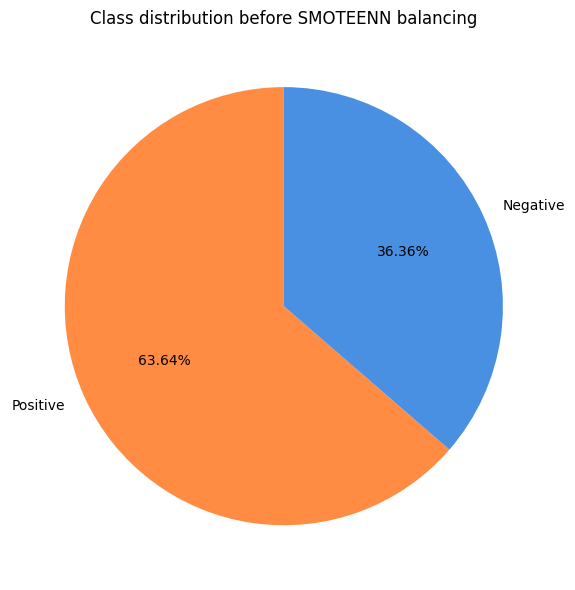

In [4]:
# Class distribution pie chart
fig, ax = plt.subplots(figsize=(6, 6))

data['MonkeyPox'].value_counts().plot.pie(
    autopct='%1.2f%%', colors=['#FF8C42', '#4A90E2'],
    ylabel='', ax=ax, startangle=90,
    labels=['Positive', 'Negative']
)
ax.set_title('Class distribution before SMOTEENN balancing')

plt.tight_layout()
plt.show()

## Feature Engineering

In [5]:
INITIAL_FEATURES = [
    'HIV Infection', 'Rectal Pain', 'Fever', 'Sexually Transmitted Infection',
    'Swollen Lymph Nodes', 'Sore Throat', 'Penile Oedema', 'Oral Lesions',
]

def engineer_features(df_in):
    """Engineer 10 additional features on top of the 8 initial-selected ones (18 total)."""
    df_out = df_in[INITIAL_FEATURES].copy()
    
    # 6 pairwise interactions among the top-4 most-correlated features
    top4 = ['HIV Infection', 'Rectal Pain', 'Fever', 'Sexually Transmitted Infection']
    for i in range(len(top4)):
        for j in range(i + 1, len(top4)):
            a, b = top4[i], top4[j]
            name = f"{a.replace(' ', '_')}_X_{b.replace(' ', '_')}"
            df_out[name] = df_in[a] * df_in[b]
    
    # Aggregate counts
    df_out['total_symptoms'] = df_in[INITIAL_FEATURES].sum(axis=1)
    high_risk = ['HIV Infection', 'Rectal Pain', 'Penile Oedema', 'Sexually Transmitted Infection']
    df_out['high_risk_count'] = df_in[high_risk].sum(axis=1)
    viral_like = ['Fever', 'Swollen Lymph Nodes', 'Sore Throat', 'Oral Lesions']
    df_out['viral_like_count'] = df_in[viral_like].sum(axis=1)
    df_out['risk_to_viral_ratio'] = df_out['high_risk_count'] / (df_out['viral_like_count'] + 1)
    
    return df_out

X_engineered = engineer_features(data)
y = data['MonkeyPox'].values.astype(np.int32)

print(f"Original 8 features, expanded to {X_engineered.shape[1]} features\n")
print("Engineered features added:")
for col in X_engineered.columns:
    if col not in INITIAL_FEATURES:
        print(f"  - {col}")

X = X_engineered.values.astype(np.float32)
N_FEATURES = X.shape[1]
print(f"\nFinal feature matrix: {X.shape}")

Original 8 features, expanded to 18 features

Engineered features added:
  - HIV_Infection_X_Rectal_Pain
  - HIV_Infection_X_Fever
  - HIV_Infection_X_Sexually_Transmitted_Infection
  - Rectal_Pain_X_Fever
  - Rectal_Pain_X_Sexually_Transmitted_Infection
  - Fever_X_Sexually_Transmitted_Infection
  - total_symptoms
  - high_risk_count
  - viral_like_count
  - risk_to_viral_ratio

Final feature matrix: (25000, 18)


In [6]:
# Verify engineered features carry useful signal, correlation with target
corr_with_target = X_engineered.copy()
corr_with_target['target'] = y
correlations = corr_with_target.corr()['target'].drop('target').abs().sort_values(ascending=False)

print("Feature correlation with target (strongest first):")
for feat, corr in correlations.items():
    marker = " [engineered]" if feat not in INITIAL_FEATURES else ""
    print(f"  {feat:45s}  {corr:.4f}{marker}")

Feature correlation with target (strongest first):
  total_symptoms                                 0.3041 [engineered]
  high_risk_count                                0.2355 [engineered]
  viral_like_count                               0.1937 [engineered]
  HIV Infection                                  0.1462
  HIV_Infection_X_Rectal_Pain                    0.1434 [engineered]
  Rectal Pain                                    0.1407
  Rectal_Pain_X_Sexually_Transmitted_Infection   0.1402 [engineered]
  HIV_Infection_X_Sexually_Transmitted_Infection  0.1398 [engineered]
  Fever                                          0.1371
  HIV_Infection_X_Fever                          0.1326 [engineered]
  Fever_X_Sexually_Transmitted_Infection         0.1253 [engineered]
  Sexually Transmitted Infection                 0.1234
  Rectal_Pain_X_Fever                            0.1177 [engineered]
  Swollen Lymph Nodes                            0.1157
  Sore Throat                                  

## 4. SMOTEENN class balancing and train/test split

In [ ]:
# Apply SMOTEENN to the entire dataset
sm = SMOTEENN(random_state=SEED)
X_balanced, y_balanced = sm.fit_resample(X, y)

print(f"Before SMOTEENN: X={X.shape}, class counts={np.bincount(y)}")
print(f"After SMOTEENN:  X={X_balanced.shape}, class counts={np.bincount(y_balanced)}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.20,
    random_state=SEED,
    stratify=y_balanced,
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test class balance:  {np.bincount(y_test)}")

Before SMOTEENN: X=(25000, 18), class counts=[ 9091 15909]
After SMOTEENN:  X=(7553, 18), class counts=[2732 4821]

Train: (6042, 18), Test: (1511, 18)
Train class balance: [2185 3857]
Test class balance:  [547 964]
